# Analyse bidimensionnelle ciblee 

Ce notebook reprend l'analyse bidimensionnelle des donnees Parcoursup du projet.

L'idee est de croiser les variables deux a deux pour voir si certains profils de formations reviennent souvent.

On va surtout regarder trois choses :
- la place des femmes parmi les admis ;
- la dimension territoriale, a travers la region de l'etablissement et la part d'admis venant de la meme academie ;
- la dimension sociale, via la part d'admis boursiers.

Point important : chaque ligne correspond a une formation, pas a un etudiant. Donc ici, on decrit des profils de formations, pas des parcours individuels.


In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 60)

# Nettoyage et preparation des donnees en Python

In [8]:
DATA_PATH = Path("Parcoursup.csv")


df_raw = pd.read_csv(DATA_PATH, sep=";")
print(f"Jeu brut : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")


def clean_cat(series: pd.Series) -> pd.Series:
    return (
        series.astype("string")
        .str.strip()
        .replace({"": pd.NA, "nan": pd.NA, "nd": pd.NA})
    )


def clean_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(clean_cat(series).str.replace(",", ".", regex=False), errors="coerce")


df = pd.DataFrame({
    "region": clean_cat(df_raw["Région de l’établissement"]),
    "academie": clean_cat(df_raw["Académie de l’établissement"]),
    "filiere": clean_cat(df_raw["Filière de formation très agrégée"]),
    "selectivite": clean_cat(df_raw["Sélectivité"]),
    "capacite": clean_num(df_raw["Capacité de l’établissement par formation"]),
    "candidats_total": clean_num(df_raw["Effectif total des candidats pour une formation"]),
    "admis_total": clean_num(df_raw["Effectif total des candidats ayant accepté la proposition de l’établissement (admis)"]),
    "pct_filles": clean_num(df_raw["% d’admis dont filles"]),
    "pct_boursiers": clean_num(df_raw["% d’admis néo bacheliers boursiers"]),
    "taux_acces": clean_num(df_raw["Taux d’accès"]),
    "pct_meme_academie": clean_num(df_raw["% d’admis néo bacheliers issus de la même académie"]),
})

df["pression"] = df["candidats_total"] / df["capacite"].replace(0, np.nan)

regions_top10 = df["region"].value_counts(dropna=True).head(10).index
df["region_groupee"] = df["region"].where(df["region"].isin(regions_top10), "Autres regions")
df["region_groupee"] = df["region_groupee"].fillna("Region non renseignee")

df["profil_genre"] = pd.cut(
    df["pct_filles"],
    bins=[-np.inf, 40, 60, np.inf],
    labels=["plus d'hommes", "Mixte", "plus de femmes"],
)
df["profil_genre"] = df["profil_genre"].astype("object").fillna("Non renseigne")

df["profil_boursier"] = pd.cut(
    df["pct_boursiers"],
    bins=[-np.inf, 15, 30, np.inf],
    labels=["Peu de boursiers", "équilibré", "bcp de boursiers"],
)
df["profil_boursier"] = df["profil_boursier"].astype("object").fillna("Non renseigne")

df["ancrage_local"] = pd.cut(
    df["pct_meme_academie"],
    bins=[-np.inf, 40, 70, np.inf],
    labels=["Faible ancrage local", "Ancrage intermediaire", "Fort ancrage local"],
)
df["ancrage_local"] = df["ancrage_local"].astype("object").fillna("Non renseigne")

analysis = df.loc[
    df[["region_groupee", "profil_genre", "profil_boursier", "pct_filles", "pct_boursiers", "taux_acces", "pression"]]
    .notna()
    .any(axis=1)
].copy()

for col in ["capacite", "candidats_total", "admis_total", "pct_filles", "pct_boursiers", "taux_acces", "pct_meme_academie", "pression"]:
    analysis[col] = pd.to_numeric(analysis[col], errors="coerce")

print(f"Jeu d'analyse : {analysis.shape[0]} lignes")
analysis.head()

Jeu brut : 14252 lignes x 118 colonnes
Jeu d'analyse : 14252 lignes


,region,academie,filiere,selectivite,capacite,candidats_total,admis_total,pct_filles,pct_boursiers,taux_acces,pct_meme_academie,pression,region_groupee,profil_genre,profil_boursier,ancrage_local
0,Auvergne-Rhône-Alpes,Lyon,Autre formation,formation sélective,40,936,40,82.0,23.0,13,31.0,23.4,Auvergne-Rhône-Alpes,plus de femmes,équilibré,Faible ancrage local
1,Ile-de-France,Créteil,Licence,formation non sélective,32,249,30,77.0,17.0,98,33.0,7.78125,Ile-de-France,plus de femmes,équilibré,Faible ancrage local
2,Auvergne-Rhône-Alpes,Lyon,IFSI,formation sélective,56,2791,56,89.0,16.0,40,84.0,49.839286,Auvergne-Rhône-Alpes,plus de femmes,équilibré,Fort ancrage local
3,Auvergne-Rhône-Alpes,Lyon,PASS,formation non sélective,195,5973,194,54.0,13.0,36,71.0,30.630769,Auvergne-Rhône-Alpes,Mixte,Peu de boursiers,Fort ancrage local
4,Auvergne-Rhône-Alpes,Lyon,PASS,formation non sélective,75,5472,75,87.0,18.0,20,75.0,72.96,Auvergne-Rhône-Alpes,plus de femmes,équilibré,Fort ancrage local


In [8]:

# Adapter le chemin si besoin
DATA_PATH = "/home/gugubre/Projet_analyse_de_donnees_vf/An2DO_4A/Rendu/Fichier_Rendu/Python/Parcoursup.csv"

# Chargement
df = pd.read_csv(DATA_PATH, sep=";", encoding="utf-8-sig")

# Conversion robuste : on tente de convertir chaque colonne en numérique
df_num = df.apply(lambda col: pd.to_numeric(col, errors="coerce"))

# On garde seulement les colonnes quantitatives avec au moins une vraie valeur numérique
df_num = df_num.loc[:, df_num.notna().any()]

# Analyse rapide
resume = pd.DataFrame({
    "type": df_num.dtypes.astype(str),
    "nb_valeurs_non_nulles": df_num.notna().sum(),
    "nb_manquants": df_num.isna().sum(),
    "%_manquants": (df_num.isna().mean() * 100).round(2),
    "moyenne": df_num.mean().round(2),
    "mediane": df_num.median().round(2),
    "ecart_type": df_num.std().round(2),
    "min": df_num.min().round(2),
    "q1": df_num.quantile(0.25).round(2),
    "q3": df_num.quantile(0.75).round(2),
    "max": df_num.max().round(2),
})

display(df_num.head())
display(resume.sort_values("%_manquants"))
display(df_num.describe().T.round(2))



,Session,Code départemental de l’établissement,Capacité de l’établissement par formation,Effectif total des candidats pour une formation,Dont effectif des candidates pour une formation,Effectif total des candidats en phase principale,Dont effectif des candidats ayant postulé en internat,Effectif des candidats néo bacheliers généraux en phase principale,Dont effectif des candidats boursiers néo bacheliers généraux en phase principale,Effectif des candidats néo bacheliers technologiques en phase principale,Dont effectif des candidats boursiers néo bacheliers technologiques en phase principale,Effectif des candidats néo bacheliers professionnels en phase principale,Dont effectif des candidats boursiers néo bacheliers professionnels en phase principale,Effectif des autres candidats en phase principale,Effectif total des candidats en phase complémentaire,Effectif des candidats néo bacheliers généraux en phase complémentaire,Effectif des candidats néo bacheliers technologique en phase complémentaire,Effectif des candidats néo bacheliers professionnels en phase complémentaire,Effectifs des autres candidats en phase complémentaire,Effectif total des candidats classés par l’établissement en phase principale,Effectif des candidats classés par l’établissement en phase complémentaire,Effectif des candidats classés par l’établissement en internat (CPGE),Effectif des candidats classés par l’établissement hors internat (CPGE),Effectif des candidats néo bacheliers généraux classés par l’établissement,Dont effectif des candidats boursiers néo bacheliers généraux classés par l’établissement,Effectif des candidats néo bacheliers technologiques classés par l’établissement,Dont effectif des candidats boursiers néo bacheliers technologiques classés par l’établissement,Effectif des candidats néo bacheliers professionnels classés par l’établissement,Dont effectif des candidats boursiers néo bacheliers professionnels classés par l’établissement,Effectif des autres candidats classés par l’établissement,Effectif total des candidats ayant reçu une proposition d’admission de la part de l’établissement,Effectif total des candidats ayant accepté la proposition de l’établissement (admis),Dont effectif des candidates admises,Effectif des admis en phase principale,Effectif des admis en phase complémentaire,Dont effectif des admis ayant reçu leur proposition d’admission à l'ouverture de la procédure principale,Dont effectif des admis ayant reçu leur proposition d’admission avant le baccalauréat,Dont effectif des admis ayant reçu leur proposition d’admission avant la fin de la procédure principale,Dont effectif des admis en internat,Dont effectif des admis boursiers néo bacheliers,Effectif des admis néo bacheliers,Effectif des admis néo bacheliers généraux,Effectif des admis néo bacheliers technologiques,Effectif des admis néo bacheliers professionnels,Effectif des autres candidats admis,Dont effectif des admis néo bacheliers sans information sur la mention au bac,Dont effectif des admis néo bacheliers sans mention au bac,Dont effectif des admis néo bacheliers avec mention Assez Bien au bac,Dont effectif des admis néo bacheliers avec mention Bien au bac,Dont effectif des admis néo bacheliers avec mention Très Bien au bac,Dont effectif des admis néo bacheliers avec mention Très Bien avec félicitations au bac,Effectif des admis néo bacheliers généraux ayant eu une mention au bac,Effectif des admis néo bacheliers technologiques ayant eu une mention au bac,Effectif des admis néo bacheliers professionnels ayant eu une mention au bac,Dont effectif des admis issus du même établissement (BTS/CPGE),Dont effectif des admises issues du même établissement (BTS/CPGE),Dont effectif des admis issus de la même académie,Dont effectif des admis issus de la même académie (Paris/Créteil/Versailles réunies),% d’admis ayant reçu leur proposition d’admission à l'ouverture de la procédure principale,% d’admis ayant reçu leur proposition d’admission avant le baccalauréat,% d’admis ayant

,type,nb_valeurs_non_nulles,nb_manquants,%_manquants,moyenne,mediane,ecart_type,min,q1,q3,max
Dont effectif des admis issus de la même académie (Paris/Créteil/Versailles réunies),int64,14252,0,0.00,26.30,14.0,48.84,0.0,7.0,27.00,1065.0
% d’admis néo bacheliers sans information sur la mention au bac,float64,14252,0,0.00,0.15,0.0,1.55,0.0,0.0,0.00,100.0
% d’admis néo bacheliers,float64,14252,0,0.00,73.18,78.0,22.75,0.0,61.0,91.00,100.0
% d’admis néo bacheliers boursiers,float64,14252,0,0.00,22.27,20.0,17.77,0.0,9.0,32.00,100.0
% d’admis néo bacheliers issus du même établissement (BTS/CPGE),float64,14252,0,0.00,10.25,0.0,19.12,0.0,0.0,12.00,100.0
...,...,...,...,...,...,...,...,...,...,...,...
Rang du dernier appelé du groupe 3,float64,3666,10586,74.28,59.86,48.0,46.60,1.0,26.0,81.00,494.0
Effectif des candidats classés par l’établissement en internat (CPGE),float64,986,13266,93.08,64.30,47.0,77.93,0.0,13.0,87.00,723.0
Dont effectif des candidats ayant postulé en internat,float64,986,13266,93.08,100.51,59.0,194.95,0.0,17.0,114.75,2729.0
Effectif des candidats classés par l’établissement hors internat (CPGE),float64,986,13266,93.08,581.35,423.0,562.71,0.0,214.0,750.00,5886.0


,count,mean,std,min,25%,50%,75%,max
Session,14252.0,2025.00,0.00,2025.0,2025.00,2025.0,2025.0,2025.0
Code départemental de l’établissement,14178.0,99.14,199.43,1.0,34.00,59.0,76.0,988.0
Capacité de l’établissement par formation,14252.0,53.98,99.85,0.0,18.00,30.0,50.0,3400.0
Effectif total des candidats pour une formation,14252.0,947.40,1584.18,1.0,160.00,385.0,1016.0,19404.0
Dont effectif des candidates pour une formation,14252.0,533.80,1037.66,0.0,58.00,193.0,529.0,14569.0
...,...,...,...,...,...,...,...,...
cod_aff_form,14252.0,18885.96,13904.54,3.0,6995.75,13637.0,29105.5,50456.0
Taux d’accès,13076.0,58.30,29.37,1.0,33.00,58.0,86.0,100.0
Part des terminales générales qui étaient en position de recevoir une proposition en phase principale,13133.0,55.24,34.56,0.0,22.00,56.0,90.0,100.0
Part des terminales technologiques qui étaient en position de recevoir une proposition en phase principale,13133.0,25.22,21.21,0.0,6.00,24.0,41.0,100.0


## 1. Lecture rapide des variables retenues

Avant de faire les croisements, on verifie d'abord que les variables choisies sont bien exploitables.

Le point le plus delicat concerne l'origine geographique des admis. La base ne donne pas directement la region d'origine de chaque candidat. Du coup, on s'appuie sur deux informations disponibles :
- la **region de l'etablissement**, pour situer la formation ;
- la part d'admis venant de la **meme academie**, pour voir si la formation recrute surtout localement ou non.

L'objectif n'est pas d'avoir une mesure parfaite, mais une lecture territoriale raisonnable avec les donnees qu'on a.

In [9]:
missing = pd.DataFrame({
    "type": analysis.dtypes.astype(str),
    "nb_manquants": analysis.isna().sum(),
    "pct_manquants": (analysis.isna().mean() * 100).round(1),
    "nb_modalites_ou_valeurs": analysis.nunique(dropna=True),
}).sort_values(["pct_manquants", "nb_modalites_ou_valeurs"], ascending=[True, False])

display(missing)

display(
    analysis[["pct_filles", "pct_boursiers", "taux_acces", "pression", "pct_meme_academie"]]
    .describe()
    .round(2)
)

,type,nb_manquants,pct_manquants,nb_modalites_ou_valeurs
pression,Float64,4,0.0,8075
candidats_total,Int64,0,0.0,3244
admis_total,Int64,0,0.0,462
capacite,Int64,0,0.0,348
pct_filles,Float64,0,0.0,101
pct_meme_academie,Float64,0,0.0,101
pct_boursiers,Float64,0,0.0,92
academie,string,0,0.0,33
filiere,string,0,0.0,11
region_groupee,string,0,0.0,11


,pct_filles,pct_boursiers,taux_acces,pression,pct_meme_academie
count,14252.0,14252.0,13076.0,14248.0,14252.0
mean,50.0,22.27,58.3,21.1,69.53
std,29.62,17.77,29.37,33.52,28.77
min,0.0,0.0,1.0,0.05,0.0
25%,25.0,9.0,33.0,6.17,52.0
50%,53.0,20.0,58.0,11.42,78.0
75%,75.0,32.0,86.0,23.5,93.0
max,100.0,100.0,100.0,904.67,100.0


## 2. Comparaisons quali-quali

On commence par des comparaisons entre variables qualitatives.

Le but est de voir s'il existe des associations visibles entre :
- le profil de genre des formations ;
- la place des boursiers ;
- le fait de recruter plutot localement ou plus largement selon les regions.

Cette premiere partie sert surtout a faire ressortir de grandes tendances avant de passer aux variables numeriques.

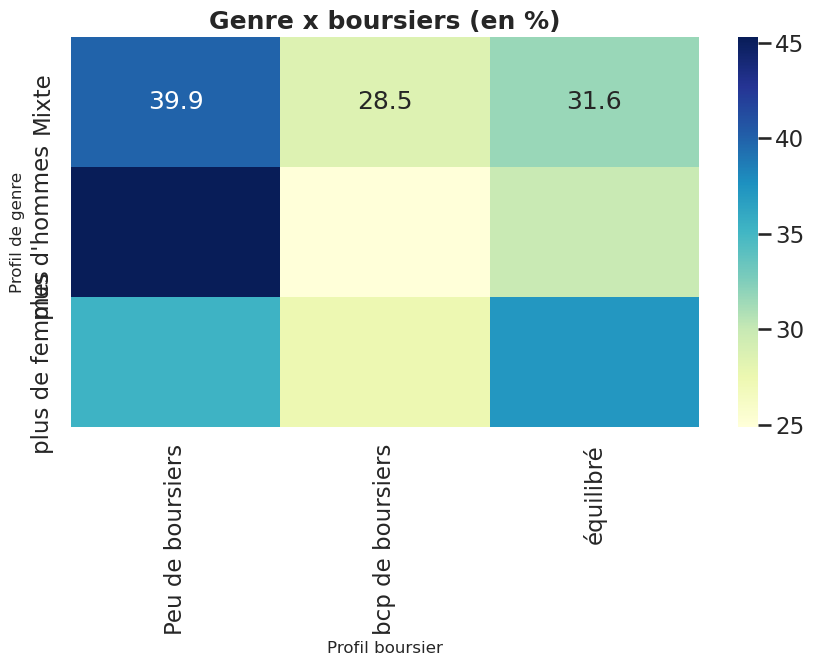

<Figure size 1000x800 with 0 Axes>

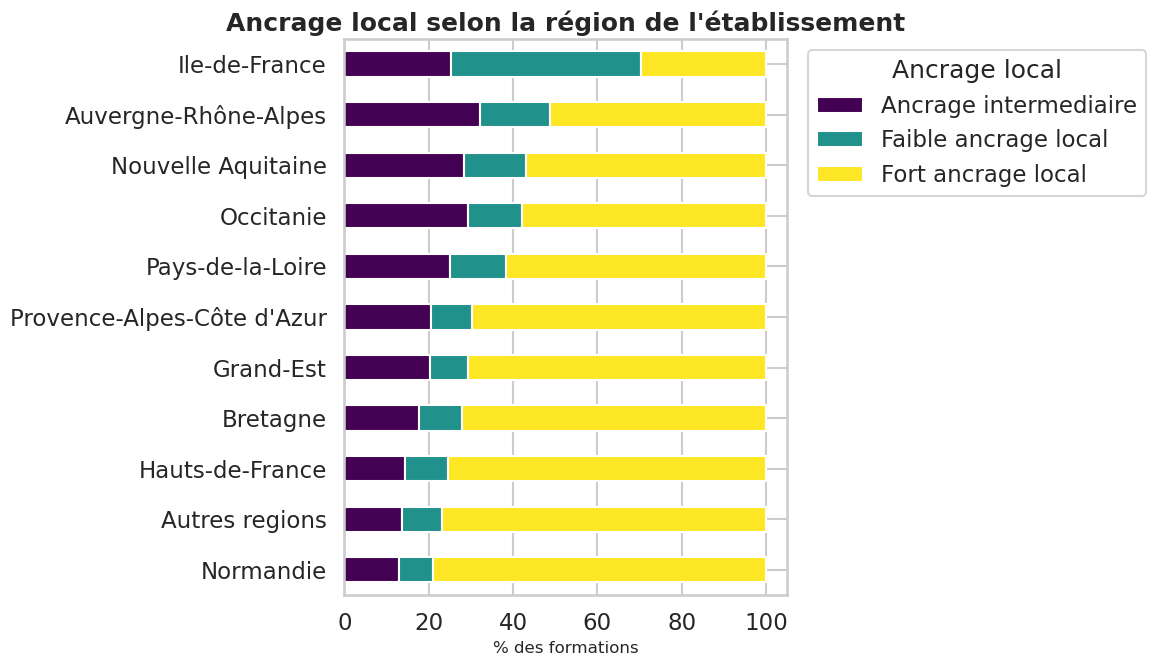

profil_boursier,Peu de boursiers,bcp de boursiers,équilibré
profil_genre,,,
Mixte,39.9,28.5,31.6
plus d'hommes,45.3,24.9,29.9
plus de femmes,35.3,27.4,37.2


ancrage_local,Ancrage intermediaire,Faible ancrage local,Fort ancrage local
region_groupee,,,
Normandie,12.8,8.1,79.1
Autres regions,13.7,9.5,76.8
Hauts-de-France,14.3,10.1,75.6
Bretagne,17.8,10.0,72.2
Grand-Est,20.3,9.1,70.6
Provence-Alpes-Côte d'Azur,20.6,9.8,69.7
Pays-de-la-Loire,25.1,13.2,61.7
Occitanie,29.3,12.8,57.9
Nouvelle Aquitaine,28.4,14.5,57.1


In [11]:
# Préparation des données
quali_df = analysis[["profil_genre", "profil_boursier", "ancrage_local", "region_groupee"]].dropna().copy()

genre_boursier = pd.crosstab(
    quali_df["profil_genre"],
    quali_df["profil_boursier"],
    normalize="index"
).mul(100)

region_ancrage = pd.crosstab(
    quali_df["region_groupee"],
    quali_df["ancrage_local"],
    normalize="index"
).mul(100)

# --- Plot 1 : Heatmap Genre x Boursier ---
plt.figure(figsize=(9, 7))
sns.heatmap(
    genre_boursier.round(1),
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)
plt.title("Genre x boursiers (en %)")
plt.xlabel("Profil boursier")
plt.ylabel("Profil de genre")
plt.tight_layout()
plt.show()


# --- Plot 2 : Barres horizontales empilées ---
plt.figure(figsize=(10, 8))

region_ancrage_sorted = region_ancrage.sort_values("Fort ancrage local", ascending=False)

region_ancrage_sorted.plot(
    kind="barh",
    stacked=True,
    colormap="viridis"
)

plt.title("Ancrage local selon la région de l'établissement")
plt.xlabel("% des formations")
plt.ylabel("")
plt.legend(title="Ancrage local", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Affichage des tables
display(genre_boursier.round(1))
display(region_ancrage_sorted.round(1).head(12))


Observations :

Le premier graphique montre qu'il existe bien quelques ecarts entre profil de genre et part de boursiers, meme si le lien reste modere. Par exemple, les formations avec plus de femmes sont un peu plus souvent dans la categorie "equilibre" que celles avec plus d'hommes.

Le deuxieme graphique est plus net sur la dimension territoriale. L'Ile-de-France se distingue clairement : la part de formations avec faible ancrage local y est beaucoup plus elevee que dans les autres regions. A l'inverse, dans beaucoup de regions, les formations recrutent surtout dans leur propre academie.

## 3. Comparaisons quanti-quanti

Cette fois, on passe aux variables numeriques pour voir si certaines evoluent ensemble.

On cherche surtout a repondre a deux questions :
- est-ce que la part de femmes et la part de boursiers vont souvent dans le meme sens ?
- est-ce que ces variables ont un lien avec l'acces a la formation, la pression ou le recrutement local ?

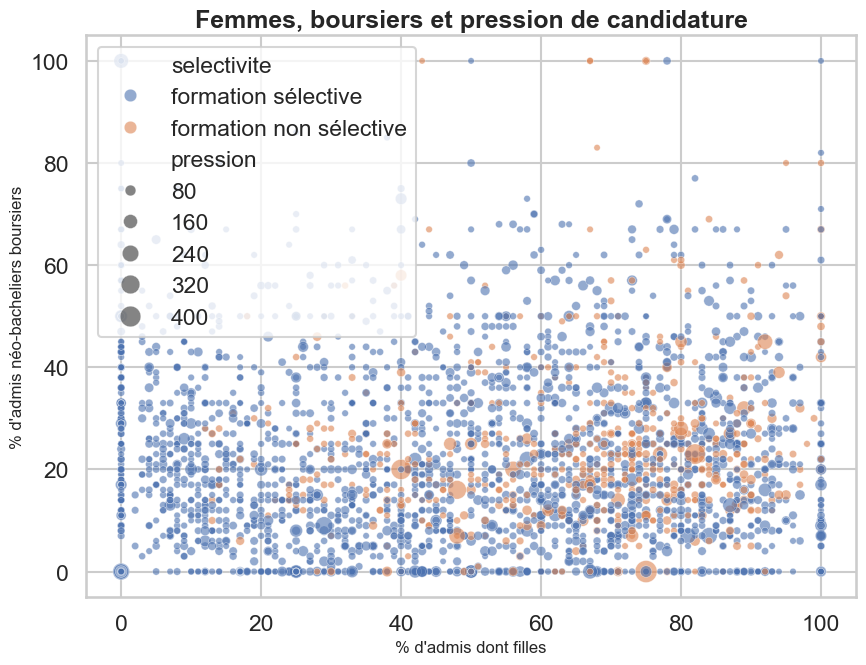

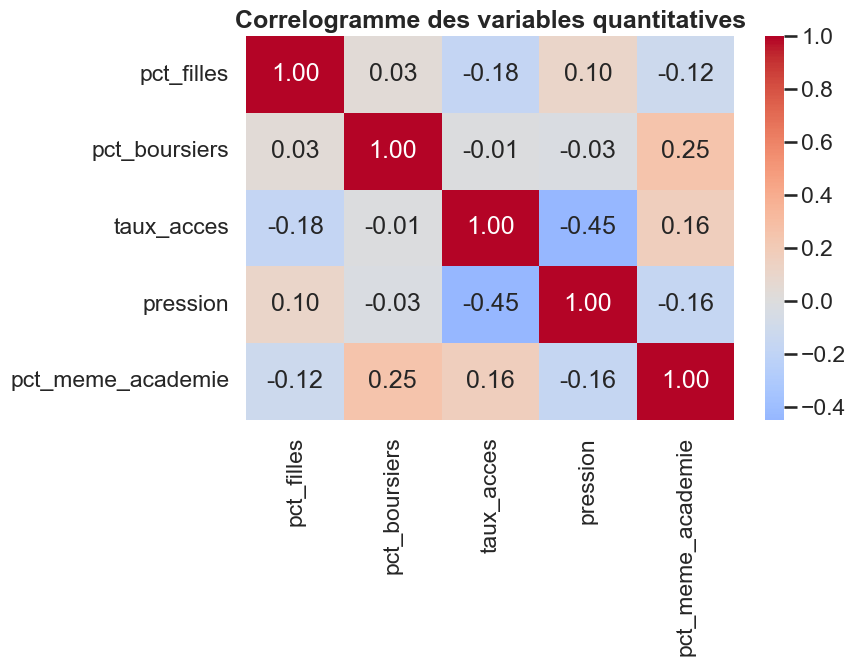

,pct_filles,pct_boursiers,taux_acces,pression,pct_meme_academie
pct_filles,1.000,0.034,-0.176,0.104,-0.121
pct_boursiers,0.034,1.000,-0.010,-0.028,0.251
taux_acces,-0.176,-0.010,1.000,-0.448,0.164
pression,0.104,-0.028,-0.448,1.000,-0.165
pct_meme_academie,-0.121,0.251,0.164,-0.165,1.000


In [ ]:
quanti_cols = ["pct_filles", "pct_boursiers", "taux_acces", "pression", "pct_meme_academie"]

quanti = analysis[quanti_cols + ["selectivite"]].dropna(
    subset=["pct_filles", "pct_boursiers", "taux_acces", "pression"]
).copy()

for col in quanti_cols:
    quanti[col] = quanti[col].astype(float)

# --- Plot 1 : scatterplot ---
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=quanti.sample(min(3000, len(quanti)), random_state=42),
    x="pct_filles",
    y="pct_boursiers",
    hue="selectivite",
    size="pression",
    sizes=(20, 250),
    alpha=0.6,
)

# plt.title("Femmes, boursiers et pression de candidature")
# plt.xlabel("% d'admis dont filles")
# plt.ylabel("% d'admis néo-bacheliers boursiers")
# plt.tight_layout()
# plt.show()


# --- Plot 2 : heatmap des corrélations ---
corr = quanti[quanti_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title("Correlation des variables quantitatives")
plt.tight_layout()
plt.show()

display(corr.round(3))

Dans l'ensemble, les correlations restent assez faibles. La relation la plus nette est celle entre la pression et le taux d'acces : plus une formation est demandee, plus le taux d'acces a tendance a baisser, ce qui est logique.

Pour le reste, il faut rester prudent. On voit plutot de petites tendances que de vrais liens tres forts. Par exemple, la part de boursiers semble un peu plus elevee dans les formations qui recrutent localement, mais ce n'est pas suffisant pour parler d'une relation massive.

## 4. Comparaisons mixtes : quali-quanti

Ici, on croise une variable de categorie avec une variable numerique pour affiner la lecture.

L'idee est de voir si certains groupes de formations se distinguent sur des indicateurs plus concrets, comme :
- le taux d'acces ;
- la pression de candidature ;
- la part de femmes ou de boursiers selon les regions ou les filieres.

C'est souvent dans cette partie qu'on voit le mieux les ecarts entre profils.

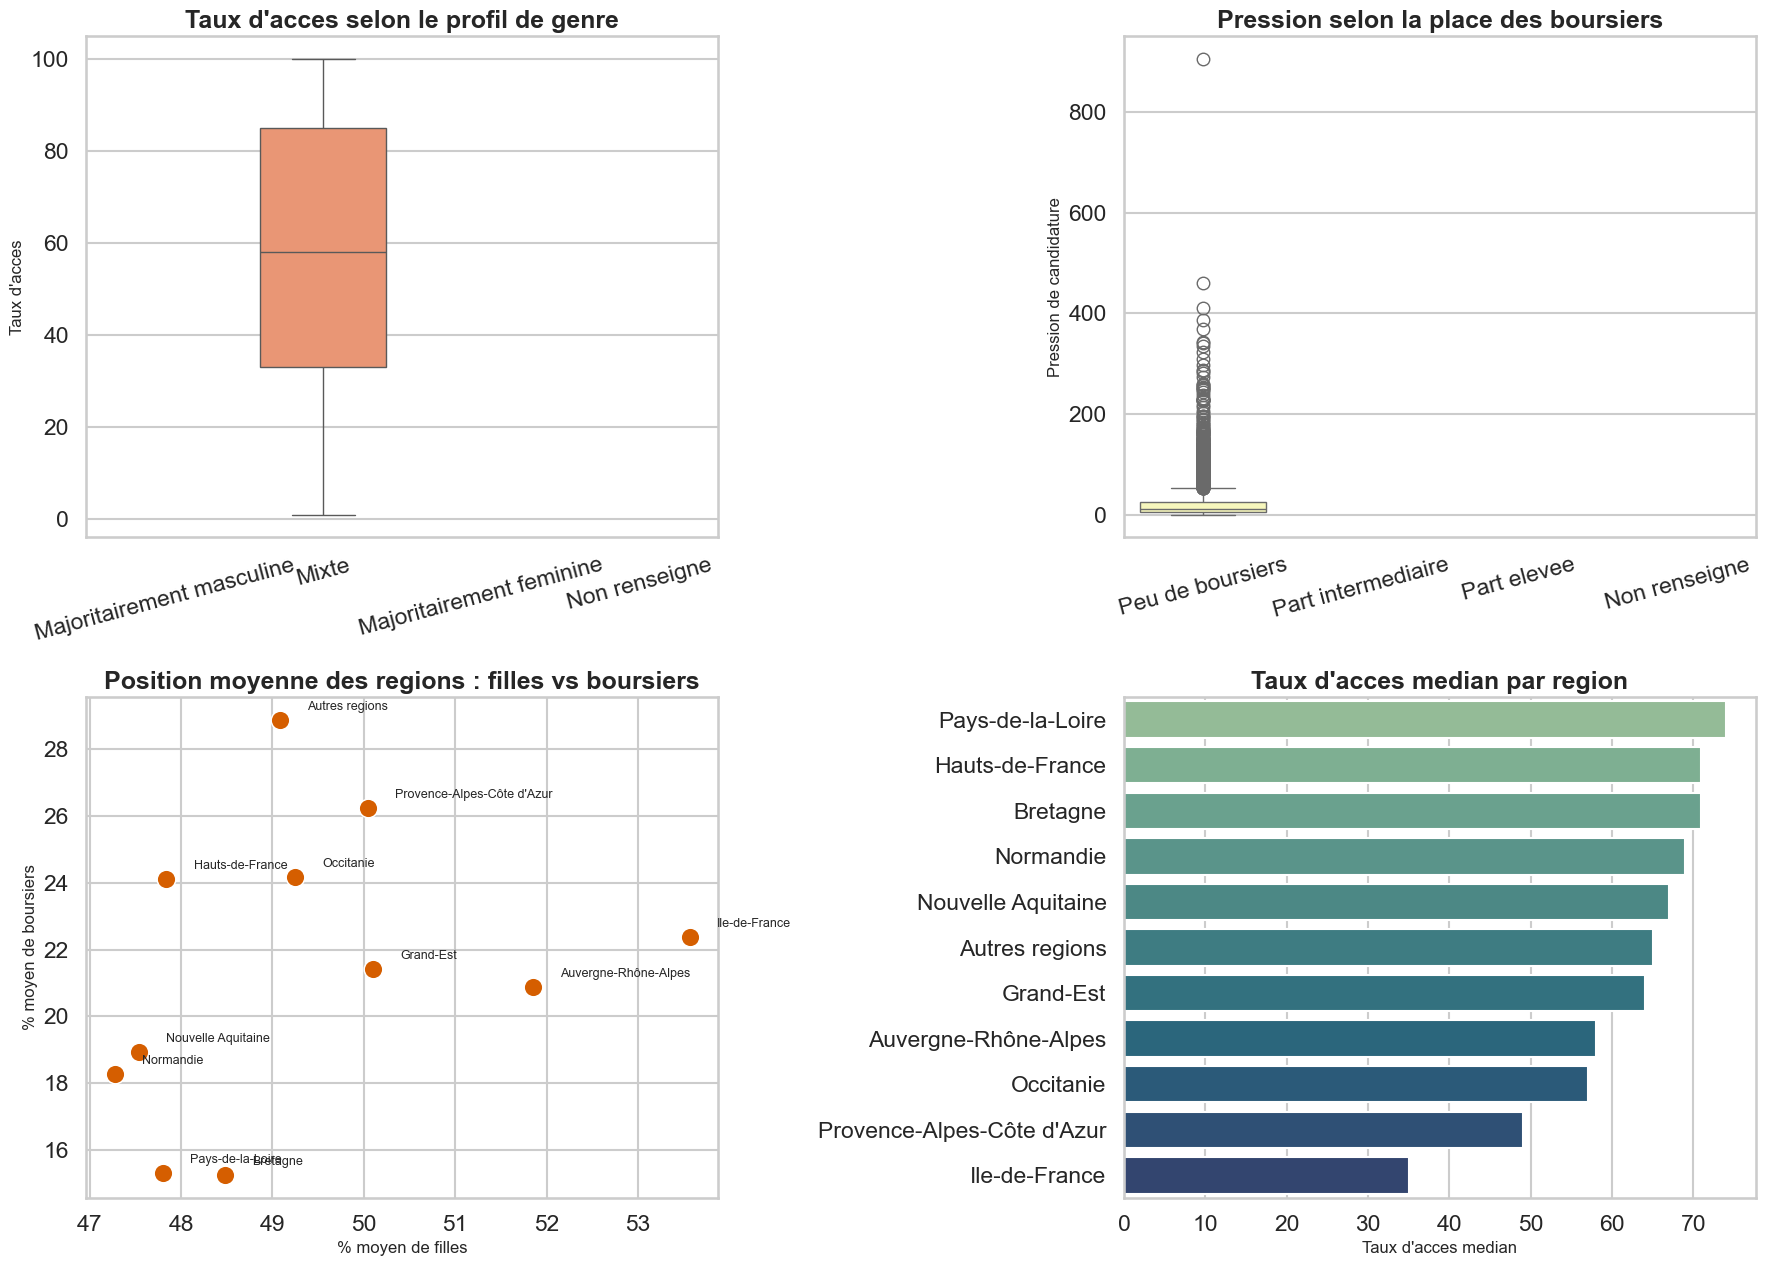

,pct_filles,pct_boursiers
region_groupee,,
Autres regions,49.08,28.87
Provence-Alpes-Côte d'Azur,50.04,26.23
Occitanie,49.25,24.18
Hauts-de-France,47.84,24.11
Ile-de-France,53.56,22.38
Grand-Est,50.09,21.41
Auvergne-Rhône-Alpes,51.85,20.89
Nouvelle Aquitaine,47.53,18.94
Normandie,47.28,18.29


In [ ]:
mix_df = analysis.copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 13))

order_genre = ["Majoritairement masculine", "Mixte", "Majoritairement feminine", "Non renseigne"]
order_boursier = ["Peu de boursiers", "Part intermediaire", "Part elevee", "Non renseigne"]

sns.boxplot(
    data=mix_df,
    x="profil_genre",
    y="taux_acces",
    order=order_genre,
    hue="profil_genre",
    palette="Set2",
    dodge=False,
    ax=axes[0, 0],
)
if axes[0, 0].legend_ is not None:
    axes[0, 0].legend_.remove()
axes[0, 0].set_title("Taux d'acces selon le profil de genre")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Taux d'acces")
axes[0, 0].tick_params(axis="x", rotation=15)

sns.boxplot(
    data=mix_df,
    x="profil_boursier",
    y="pression",
    order=order_boursier,
    hue="profil_boursier",
    palette="Set3",
    dodge=False,
    ax=axes[0, 1],
)
if axes[0, 1].legend_ is not None:
    axes[0, 1].legend_.remove()
axes[0, 1].set_title("Pression selon la place des boursiers")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Pression de candidature")
axes[0, 1].tick_params(axis="x", rotation=15)

region_summary = (
    mix_df.groupby("region_groupee")[["pct_filles", "pct_boursiers"]]
    .mean()
    .sort_values("pct_boursiers", ascending=False)
)

sns.scatterplot(
    data=region_summary.reset_index(),
    x="pct_filles",
    y="pct_boursiers",
    s=180,
    color="#d55e00",
    ax=axes[1, 0],
)
for _, row in region_summary.reset_index().iterrows():
    axes[1, 0].text(row["pct_filles"] + 0.3, row["pct_boursiers"] + 0.3, row["region_groupee"], fontsize=9)
axes[1, 0].set_title("Position moyenne des regions : filles vs boursiers")
axes[1, 0].set_xlabel("% moyen de filles")
axes[1, 0].set_ylabel("% moyen de boursiers")

acces_region = (
    mix_df.groupby("region_groupee")[["taux_acces"]]
    .median()
    .sort_values("taux_acces", ascending=False)
    .head(12)
)
sns.barplot(
    data=acces_region.reset_index(),
    x="taux_acces",
    y="region_groupee",
    hue="region_groupee",
    palette="crest",
    dodge=False,
    legend=False,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Taux d'acces median par region")
axes[1, 1].set_xlabel("Taux d'acces median")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()

display(region_summary.round(2))

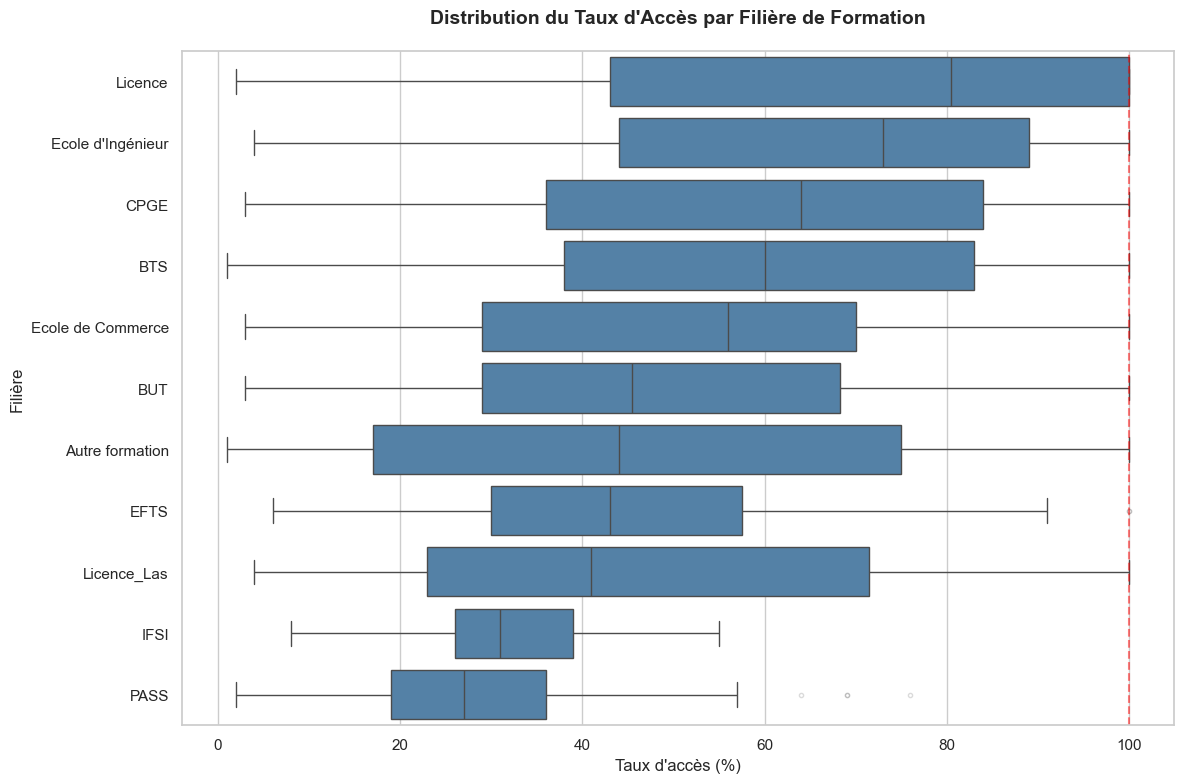

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcul de l'ordre des filières par taux d'accès médian (pour un graphique lisible)
# On trie pour avoir les filières les plus sélectives (bas taux d'accès) en haut
filiere_order = (
    analysis.groupby("filiere")["taux_acces"]
    .median()
    .sort_values(ascending=False)
    .index
)

# 2. Création du graphique
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=analysis,
    x="taux_acces",
    y="filiere",
    order=filiere_order,
    color="steelblue",
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.2} # Outliers discrets
)

# 3. Personnalisation esthétique
plt.title("Distribution du Taux d'Accès par Filière de Formation", fontsize=14, pad=20)
plt.xlabel("Taux d'accès (%)", fontsize=12)
plt.ylabel("Filière", fontsize=12)

# Ajout d'une ligne verticale à 100% pour la référence
plt.axvline(x=100, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Les IFSI et les PASS ne sont pas forcement les formations les plus selectives au sens strict, mais elles font partie de celles ou le taux d'acces est le plus faible. En clair, il y a beaucoup de demandes pour un nombre de places qui reste limite.

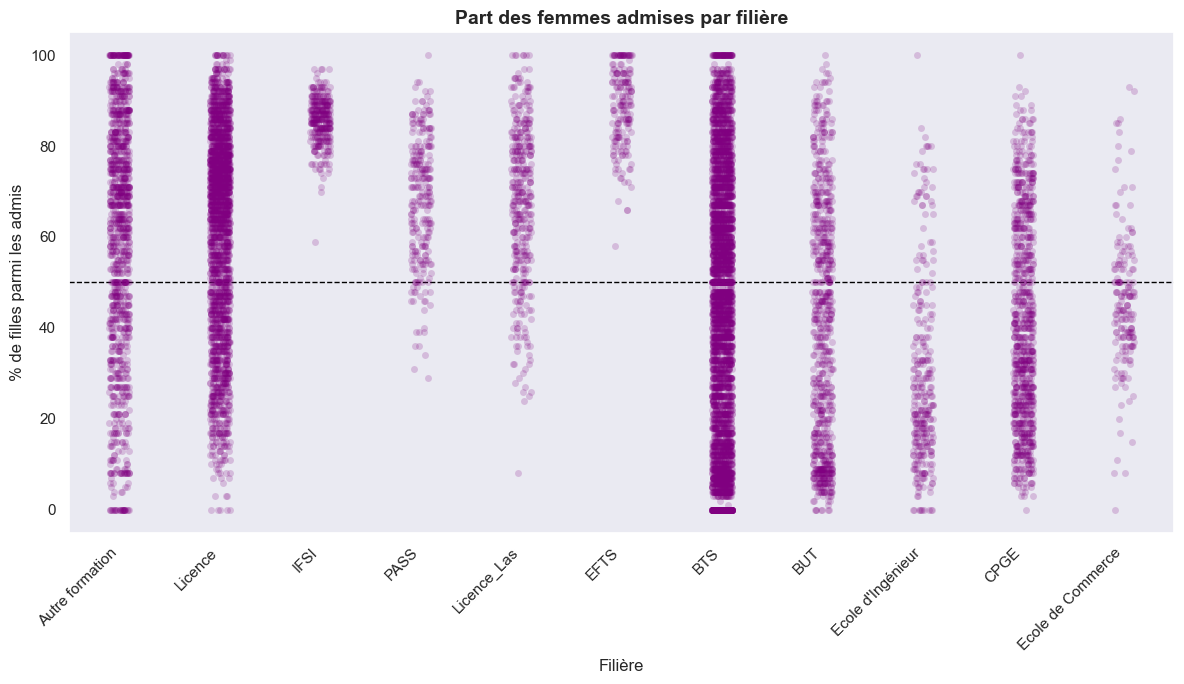

In [ ]:


# 1. Filtrage pour la lisibilité (équivalent de log_admis > 2)
# exp(2) ≈ 7.4, donc on filtre les formations de moins de 10 admis
data_genre = analysis[analysis['admis_total'] > 10].copy()

# Création du graphique
plt.figure(figsize=(12, 7))
sns.set_theme(style="dark")

# Stripplot avec jitter (dispersion aléatoire pour éviter les superpositions)
sns.stripplot(
    data=data_genre, 
    x="filiere", 
    y="pct_filles", 
    jitter=True, 
    alpha=0.2, 
    color="purple"
)

#Ajout de la ligne d'équilibre (50%)
# Note : on utilise 50 car votre pct_filles semble être sur 100 d'après vos conclusions précédentes
plt.axhline(y=50, color='black', linestyle='--', linewidth=1)

# 4. Personnalisation des axes et titres
plt.title("Part des femmes admises par filière", fontsize=14)
plt.xlabel("Filière")
plt.ylabel("% de filles parmi les admis")

# Rotation des étiquettes de l'axe X (45 degrés)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Le graphique confirme que les IFSI, et aussi les PASS, font partie des filieres les plus feminisees. La repartition femmes-hommes n'est donc pas du tout la meme selon les filieres.

## 5. Tableau de synthese interpretable

On termine par un petit tableau de synthese pour rassembler les profils qui ressortent le plus.

L'interet, c'est d'avoir en un coup d'oeil :
- le nombre de formations dans chaque profil ;
- leur taux d'acces median ;
- leur pression mediane ;
- leur part locale mediane.

Le tableau ne remplace pas les graphiques, mais il permet de verifier rapidement si les impressions visuelles tiennent encore quand on resume les donnees.

In [ ]:
synthese = (
    mix_df.groupby(["profil_genre", "profil_boursier"])
    .agg(
        nb_formations=("filiere", "size"),
        taux_acces_median=("taux_acces", "median"),
        pression_mediane=("pression", "median"),
        part_locale_mediane=("pct_meme_academie", "median"),
    )
    .sort_values(["nb_formations", "taux_acces_median"], ascending=[False, False])
)

display(synthese.round(2).head(15))

nb_formations  taux_acces_median  \
profil_genre   profil_boursier                                      
plus d'hommes  Peu de boursiers           2431               69.0   
plus de femmes équilibré                  2242               49.0   
               Peu de boursiers           2129               47.0   
               bcp de boursiers           1652               50.0   
plus d'hommes  équilibré                  1604               67.0   
               bcp de boursiers           1336               62.5   
Mixte          Peu de boursiers           1140               59.5   
               équilibré                   903               60.0   
               bcp de boursiers            815               55.0   

                                 pression_mediane  part_locale_mediane  
profil_genre   profil_boursier                                          
plus d'hommes  Peu de boursiers             10.67                 71.0  
plus de femmes équilibré                    13.39                 76.0  
               Peu de boursiers             12.92                 62.0  
               bcp de boursiers             12.53                 83.0  
plus d'hommes  équilibré                     9.78                 83.0  
               bcp de boursiers              9.06                 90.0  
Mixte          Peu de boursiers             12.47                 69.0  
               équilibré                    11.83                 80.0  
               bcp de boursiers              12.5                 89.0

Interpretation :

Le tableau confirme plusieurs idees vues plus haut.

D'abord, les formations "plus d'hommes" avec peu de boursiers sont les plus nombreuses, et ce sont aussi celles qui ont le taux d'acces median le plus eleve. A l'inverse, les formations "plus de femmes" ont souvent des taux d'acces plus bas, autour de 47 a 50 selon le profil boursier.

Ensuite, plus la part de boursiers augmente, plus la part d'admis venant de la meme academie a tendance a monter elle aussi. Cela va dans le sens d'un recrutement plus local.

Au final, on ne voit pas une opposition tres brutale entre tous les profils, mais trois tendances ressortent quand meme assez bien : un effet de filiere sur le genre, un effet territorial visible, et un lien modere entre recrutement local et presence de boursiers.